# Data Analysis — DIP-IMU Dataset

Explores the training and test `.pt` files: structure, shapes, value ranges, signal quality,
and dataset-level statistics useful for training decisions.

In [1]:
import sys
sys.path.insert(0, '..')

import os
import csv
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from tqdm.auto import tqdm

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT         = Path('../parsed_30gigs')
TRAIN_DIR    = ROOT / 'DIP_IMU_train_real_imu_position_only'
TEST_DIR     = ROOT / 'DIP_IMU_test_real_imu_position_only'
FULL_TEST_DIR= ROOT / 'DIP_IMU_test'
CSV_PATH     = ROOT / 'DIP_IMU_train_real_imu_position_only.csv'

train_files = sorted(TRAIN_DIR.glob('*.pt'))
test_files  = sorted(TEST_DIR.glob('*.pt'))

print(f'Train segments : {len(train_files)}')
print(f'Test sequences : {len(test_files)}')

# ── SMPL joint names ──────────────────────────────────────────────────────────
JOINT_NAMES = [
    'pelvis', 'left_hip', 'right_hip', 'spine1',
    'left_knee', 'right_knee', 'spine2',
    'left_ankle', 'right_ankle', 'spine3',
    'left_foot', 'right_foot', 'neck',
    'left_collar', 'right_collar', 'head',
    'left_shoulder', 'right_shoulder',
    'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist',
    'left_hand', 'right_hand',
]
N_JOINTS = 24

# SMPL skeleton edges for visualisation
SMPL_EDGES = [
    (0,1),(0,2),(0,3),(1,4),(2,5),(3,6),(4,7),(5,8),(6,9),
    (7,10),(8,11),(9,12),(9,13),(9,14),(12,15),
    (13,16),(14,17),(16,18),(17,19),(18,20),(19,21),(20,22),(21,23),
]

# IMU sensor-to-joint mapping (17 real IMU sensors → SMPL joint indices)
IMU_JOINTS = [7, 8, 10, 11, 20, 21, 0, 2, 5, 17, 19, 1, 4, 16, 18, 15, 9]
IMU_NAMES  = [JOINT_NAMES[j] for j in IMU_JOINTS]
print(f'IMU sensor joints: {IMU_NAMES}')

Train segments : 885
Test sequences : 19
IMU sensor joints: ['left_ankle', 'right_ankle', 'left_foot', 'right_foot', 'left_wrist', 'right_wrist', 'pelvis', 'right_hip', 'right_knee', 'right_shoulder', 'right_elbow', 'left_hip', 'left_knee', 'left_shoulder', 'left_elbow', 'head', 'spine3']


/Users/aliasgar/Desktop/Ali Asgar/Projects/IMUCOCO/IMUCoCo/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1 — Dataset Overview

Train subjects: ['s_01', 's_02', 's_03', 's_04', 's_05', 's_06', 's_07', 's_08']
Test  subjects: ['s_09', 's_10']

Segments per train subject:
  s_01: 116 segments  (580s @ 60 fps)
  s_02: 111 segments  (555s @ 60 fps)
  s_03: 114 segments  (570s @ 60 fps)
  s_04: 105 segments  (525s @ 60 fps)
  s_05: 115 segments  (575s @ 60 fps)
  s_06: 114 segments  (570s @ 60 fps)
  s_07: 104 segments  (520s @ 60 fps)
  s_08: 106 segments  (530s @ 60 fps)


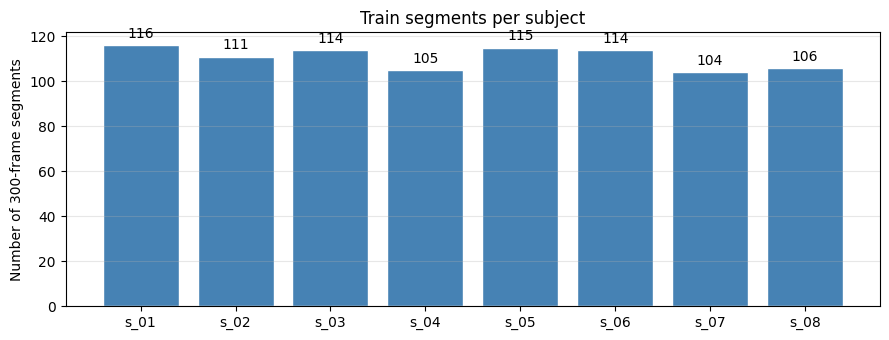

In [2]:
# ── Subject breakdown ─────────────────────────────────────────────────────────
def subject_id(path): return '_'.join(path.stem.split('_')[:2])

train_subjects = sorted(set(subject_id(f) for f in train_files))
test_subjects  = sorted(set(subject_id(f) for f in test_files))
seg_counts     = Counter(subject_id(f) for f in train_files)

print('Train subjects:', train_subjects)
print('Test  subjects:', test_subjects)
print()
print('Segments per train subject:')
for s in train_subjects:
    print(f'  {s}: {seg_counts[s]} segments  ({seg_counts[s] * 300 / 60:.0f}s @ 60 fps)')

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3.5))
bars = ax.bar(train_subjects, [seg_counts[s] for s in train_subjects],
              color='steelblue', edgecolor='white')
ax.bar_label(bars, padding=3)
ax.set_ylabel('Number of 300-frame segments')
ax.set_title('Train segments per subject')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2 — Data Structure Walk-through

In [3]:
sample = torch.load(train_files[0], map_location='cpu', weights_only=False)

print('Top-level keys:', list(sample.keys()))
print()
for top_key, sub in sample.items():
    if isinstance(sub, dict):
        print(f'[{top_key}]')
        for k, v in sub.items():
            if hasattr(v, 'shape'):
                print(f'  {k:<20} shape={tuple(v.shape)}  dtype={v.dtype}')
            else:
                print(f'  {k:<20} {type(v).__name__}')
    print()

print('Notes:')
print('  vimu_joints  [T, 24,  9] — virtual IMU at each SMPL joint (accel + gyro + ?)')
print('  imu          [T, 17,  9] — real IMU from 17 physical sensors')
print('  position     [T, 24,  3] — global 3D joint positions (metres)')
print('  velocity     [T, 24,  3] — joint velocities')
print('  orientation  [T, 24, 3,3]— rotation matrices')
print('  ft_contact   [T,  2]     — binary foot contact (left, right)')
print('  pose_local   [T, 24, 3,3]— local joint rotations (ground truth)')

Top-level keys: ['joint', 'imu', 'vimu', 'gt']

[joint]
  orientation          shape=(300, 24, 3, 3)  dtype=torch.float32
  velocity             shape=(300, 24, 3)  dtype=torch.float32
  position             shape=(300, 24, 3)  dtype=torch.float32
  asp_position         shape=(300, 24, 3)  dtype=torch.float32
  asp_velocity         shape=(300, 24, 3)  dtype=torch.float32

[imu]
  imu                  shape=(300, 17, 9)  dtype=torch.float32

[vimu]
  vimu_joints          shape=(300, 24, 9)  dtype=torch.float32
  vimu_mesh            NoneType

[gt]
  pose_local           shape=(300, 24, 3, 3)  dtype=torch.float32
  tran                 NoneType
  ft_contact           shape=(300, 2)  dtype=torch.int32

Notes:
  vimu_joints  [T, 24,  9] — virtual IMU at each SMPL joint (accel + gyro + ?)
  imu          [T, 17,  9] — real IMU from 17 physical sensors
  position     [T, 24,  3] — global 3D joint positions (metres)
  velocity     [T, 24,  3] — joint velocities
  orientation  [T, 24, 3,3]— rot

---
## 3 — Sequence Length Distribution

Train: all segments are T=300 frames (5s @ 60 fps)
Train total frames: 265,500  (73.8 hours)

Test sequence lengths (frames):
  s_09_01_a.pt            T= 4757  (79.3s)
  s_09_01_b.pt            T= 2641  (44.0s)
  s_09_01_c.pt            T= 2136  (35.6s)
  s_09_02_a.pt            T= 2767  (46.1s)
  s_09_02_b.pt            T= 2559  (42.6s)
  s_09_03_a.pt            T= 2907  (48.5s)
  s_09_03_b.pt            T= 3015  (50.2s)
  s_09_04.pt              T= 1188  (19.8s)
  s_09_05.pt              T= 4539  (75.7s)
  s_10_01_a.pt            T= 5609  (93.5s)
  s_10_01_b.pt            T= 3330  (55.5s)
  s_10_01_c.pt            T= 2284  (38.1s)
  s_10_02.pt              T= 3619  (60.3s)
  s_10_03_a.pt            T= 3038  (50.6s)
  s_10_03_b.pt            T= 3751  (62.5s)
  s_10_04_a.pt            T=  865  (14.4s)
  s_10_04_b.pt            T= 1511  (25.2s)
  s_10_04_c.pt            T= 2051  (34.2s)
  s_10_05.pt              T= 5427  (90.5s)
Test total frames: 57,994


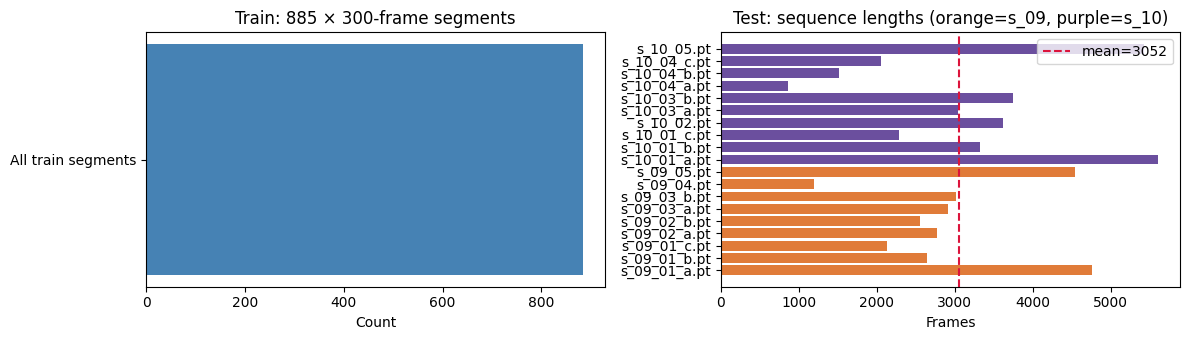

In [4]:
# Train: all fixed at T=300 (windowed)
# Test:  variable-length full sequences
test_lens = {}
for f in test_files:
    d = torch.load(f, map_location='cpu', weights_only=False)
    test_lens[f.name] = d['vimu']['vimu_joints'].shape[0]

print('Train: all segments are T=300 frames (5s @ 60 fps)')
print(f'Train total frames: {len(train_files) * 300:,}  ({len(train_files)*300/60/60:.1f} hours)')
print()
print('Test sequence lengths (frames):')
for name, T in test_lens.items():
    print(f'  {name:<22}  T={T:>5}  ({T/60:.1f}s)')
print(f'Test total frames: {sum(test_lens.values()):,}')

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

# Train: all 300, just show as constant
axes[0].barh(['All train segments'], [len(train_files)], color='steelblue')
axes[0].set_xlabel('Count')
axes[0].set_title(f'Train: {len(train_files)} × 300-frame segments')

# Test: variable lengths
names = list(test_lens.keys())
lens  = list(test_lens.values())
colors = ['#e07b39' if 's_09' in n else '#6b4f9e' for n in names]
axes[1].barh(names, lens, color=colors)
axes[1].axvline(np.mean(lens), color='crimson', linestyle='--', label=f'mean={np.mean(lens):.0f}')
axes[1].set_xlabel('Frames')
axes[1].set_title('Test: sequence lengths (orange=s_09, purple=s_10)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 4 — Kinematic Energy Distribution (from CSV)

Kinematic energy  —  global:  mean=0.2860  std=0.3239
                              min=0.0000   max=2.3321

  s_01:  mean=0.2567  std=0.3237  min=0.0026  max=2.1672
  s_02:  mean=0.3719  std=0.2950  min=0.0001  max=1.2417
  s_03:  mean=0.2176  std=0.3012  min=0.0008  max=2.1630
  s_04:  mean=0.3090  std=0.3482  min=0.0008  max=2.3321
  s_05:  mean=0.3044  std=0.3703  min=0.0002  max=2.1244
  s_06:  mean=0.2779  std=0.3198  min=0.0041  max=2.1968
  s_07:  mean=0.2784  std=0.3074  min=0.0024  max=1.8443
  s_08:  mean=0.2751  std=0.2935  min=0.0000  max=1.7392


/var/folders/b9/bslcg5p949522myh51h02xt40000gn/T/ipykernel_137/1213994391.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_boxes, labels=train_subjects, patch_artist=True,


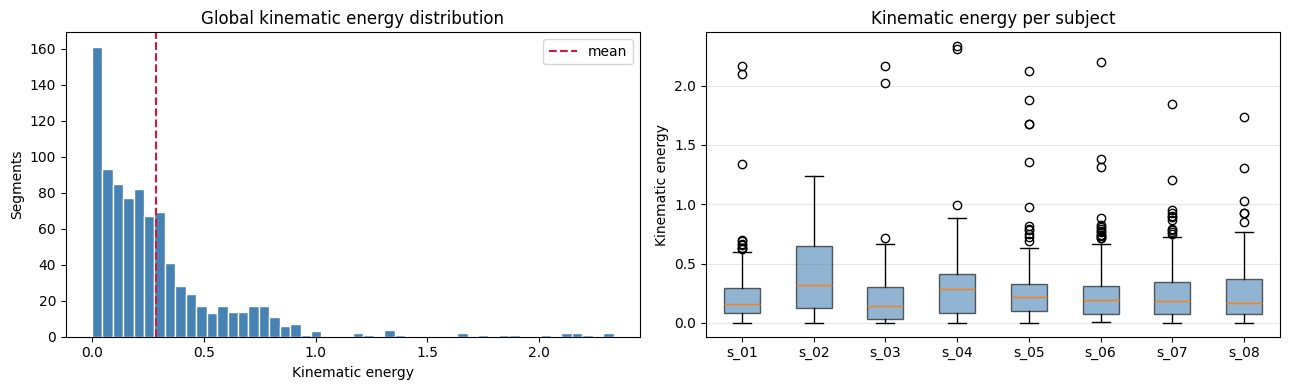

In [5]:
with open(CSV_PATH) as f:
    rows = list(csv.DictReader(f))

ke_by_subject = {}
for row in rows:
    subj = '_'.join(row['file_name'].split('_')[:2])
    ke_by_subject.setdefault(subj, []).append(float(row['kinematic_energy']))

all_ke = [float(r['kinematic_energy']) for r in rows]
print(f'Kinematic energy  —  global:  mean={np.mean(all_ke):.4f}  std={np.std(all_ke):.4f}')
print(f'                              min={np.min(all_ke):.4f}   max={np.max(all_ke):.4f}')
print()
for s in train_subjects:
    ke = ke_by_subject[s]
    print(f'  {s}:  mean={np.mean(ke):.4f}  std={np.std(ke):.4f}  min={np.min(ke):.4f}  max={np.max(ke):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Global histogram
axes[0].hist(all_ke, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(all_ke), color='crimson', linestyle='--', label='mean')
axes[0].set_xlabel('Kinematic energy')
axes[0].set_ylabel('Segments')
axes[0].set_title('Global kinematic energy distribution')
axes[0].legend()

# Per-subject box plots
data_boxes = [ke_by_subject[s] for s in train_subjects]
axes[1].boxplot(data_boxes, labels=train_subjects, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_ylabel('Kinematic energy')
axes[1].set_title('Kinematic energy per subject')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5 — Joint Position Analysis

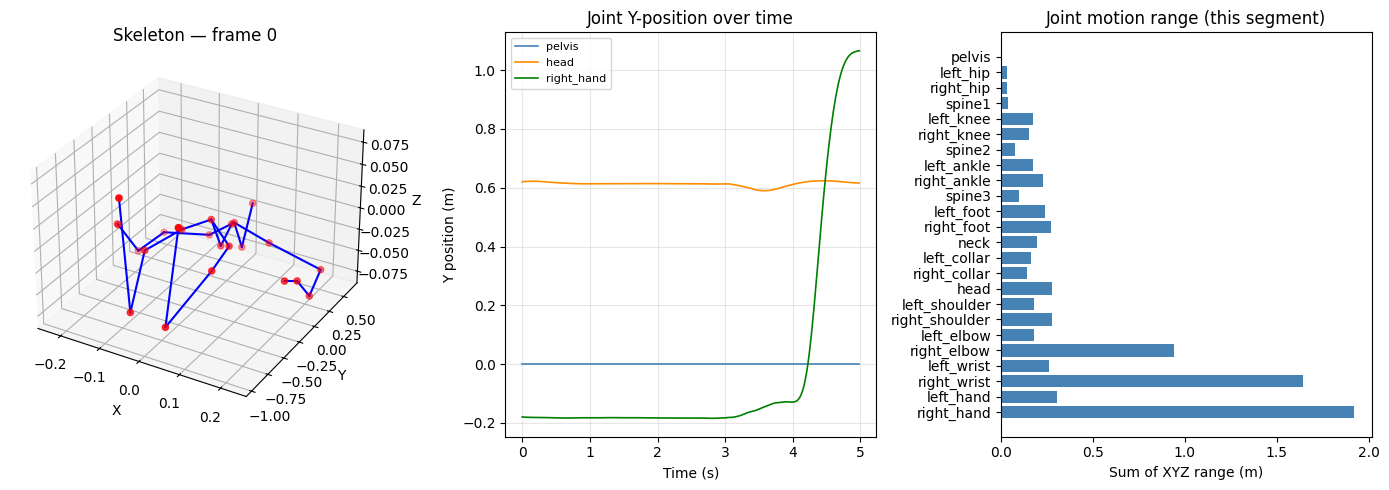

In [6]:
d = torch.load(train_files[0], map_location='cpu', weights_only=False)
pos = d['joint']['position'].numpy()   # [300, 24, 3]

# ── 3D skeleton at frame 0 ────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))

ax3d = fig.add_subplot(131, projection='3d')
p0 = pos[0]   # [24, 3]
for i, j in SMPL_EDGES:
    ax3d.plot([p0[i,0], p0[j,0]], [p0[i,1], p0[j,1]], [p0[i,2], p0[j,2]], 'b-', lw=1.5)
ax3d.scatter(p0[:,0], p0[:,1], p0[:,2], c='red', s=20, zorder=5)
ax3d.set_title('Skeleton — frame 0')
ax3d.set_xlabel('X'); ax3d.set_ylabel('Y'); ax3d.set_zlabel('Z')

# ── Joint trajectory over time (pelvis, head, right_hand) ─────────────────────
ax_traj = fig.add_subplot(132)
joints_to_plot = [0, 15, 23]   # pelvis, head, right_hand
colors_traj = ['steelblue', 'darkorange', 'green']
t_ax = np.arange(pos.shape[0]) / 60.0
for ji, c in zip(joints_to_plot, colors_traj):
    ax_traj.plot(t_ax, pos[:, ji, 1], label=JOINT_NAMES[ji], color=c, lw=1.2)
ax_traj.set_xlabel('Time (s)')
ax_traj.set_ylabel('Y position (m)')
ax_traj.set_title('Joint Y-position over time')
ax_traj.legend(fontsize=8)
ax_traj.grid(alpha=0.3)

# ── Per-joint global position range (spread across 300 frames) ────────────────
ax_range = fig.add_subplot(133)
ranges = pos.max(axis=0) - pos.min(axis=0)   # [24, 3]
total_range = ranges.sum(axis=1)              # [24]
ax_range.barh(JOINT_NAMES, total_range, color='steelblue')
ax_range.set_xlabel('Sum of XYZ range (m)')
ax_range.set_title('Joint motion range (this segment)')
ax_range.invert_yaxis()

plt.tight_layout()
plt.show()

---
## 6 — Real IMU Signal Analysis

IMU shape: (300, 17, 9)  (T=300, sensors=17, channels=9)
Channel ranges:  accel(0-2)=-1.00..1.00
                 gyro (3-5)=-0.99..1.00
                 ch   (6-8)=-13.71..21.23


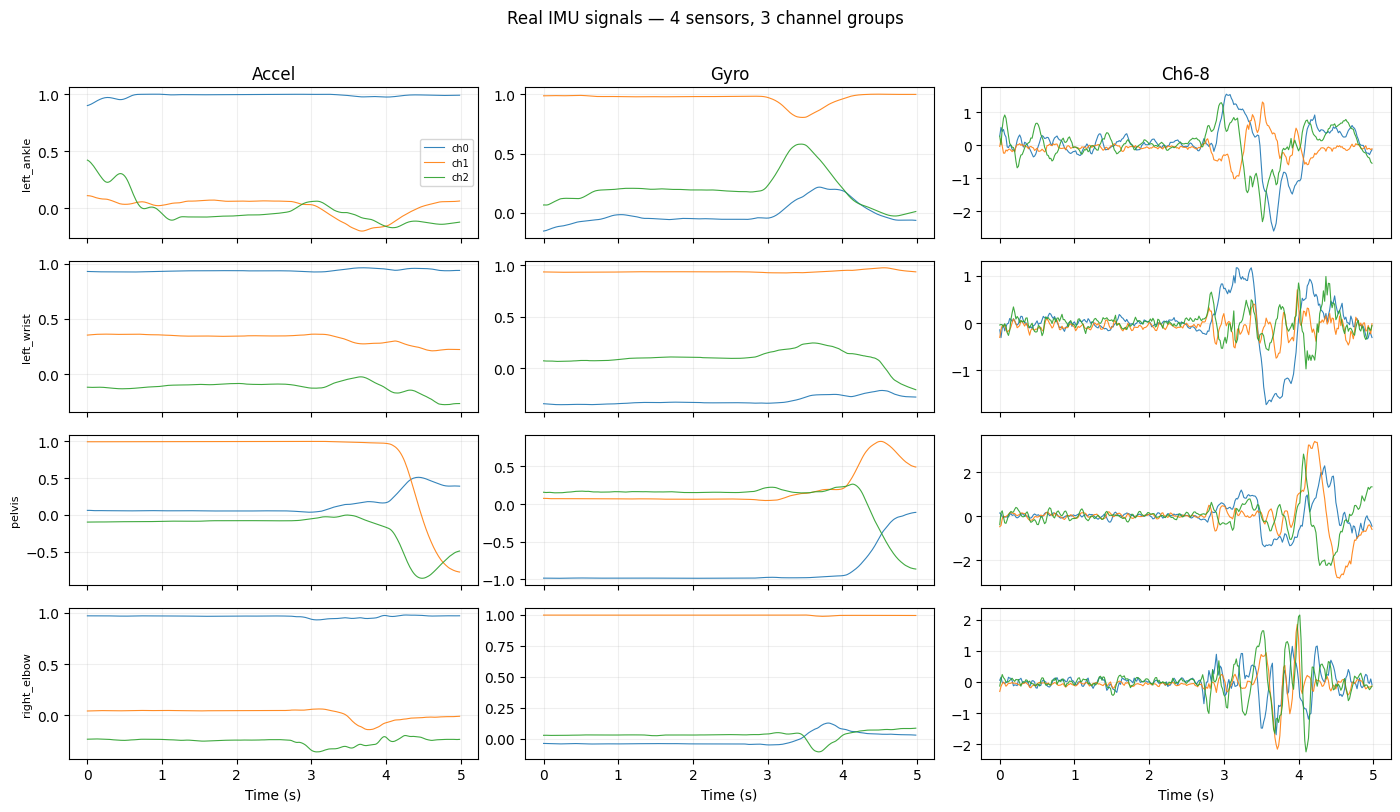

In [7]:
imu = d['imu']['imu'].numpy()   # [300, 17, 9]
# Channels 0-2: linear acceleration, 3-5: angular velocity (gyro), 6-8: unknown (likely orientation-derived)
t_ax = np.arange(imu.shape[0]) / 60.0

print(f'IMU shape: {imu.shape}  (T=300, sensors=17, channels=9)')
print(f'Channel ranges:  accel(0-2)={imu[:,:,:3].min():.2f}..{imu[:,:,:3].max():.2f}')
print(f'                 gyro (3-5)={imu[:,:,3:6].min():.2f}..{imu[:,:,3:6].max():.2f}')
print(f'                 ch   (6-8)={imu[:,:,6:].min():.2f}..{imu[:,:,6:].max():.2f}')

# Plot 4 sensors × 3 channel groups
sensors_to_show = [0, 4, 6, 10]   # left_ankle, left_wrist, pelvis, right_elbow
channel_groups  = [(0,3,'Accel'), (3,6,'Gyro'), (6,9,'Ch6-8')]

fig, axes = plt.subplots(len(sensors_to_show), len(channel_groups),
                          figsize=(14, 8), sharex=True)
for row, si in enumerate(sensors_to_show):
    for col, (c0, c1, label) in enumerate(channel_groups):
        ax = axes[row, col]
        for ch in range(c0, c1):
            ax.plot(t_ax, imu[:, si, ch], lw=0.8, alpha=0.9,
                    label=f'ch{ch}' if row == 0 else None)
        if row == 0:
            ax.set_title(label)
        if col == 0:
            ax.set_ylabel(IMU_NAMES[si], fontsize=8)
        ax.grid(alpha=0.2)

axes[0, 0].legend(fontsize=7)
for ax in axes[-1]:
    ax.set_xlabel('Time (s)')
fig.suptitle('Real IMU signals — 4 sensors, 3 channel groups', y=1.01)
plt.tight_layout()
plt.show()

---
## 7 — Virtual IMU (vimu_joints) vs Real IMU Comparison

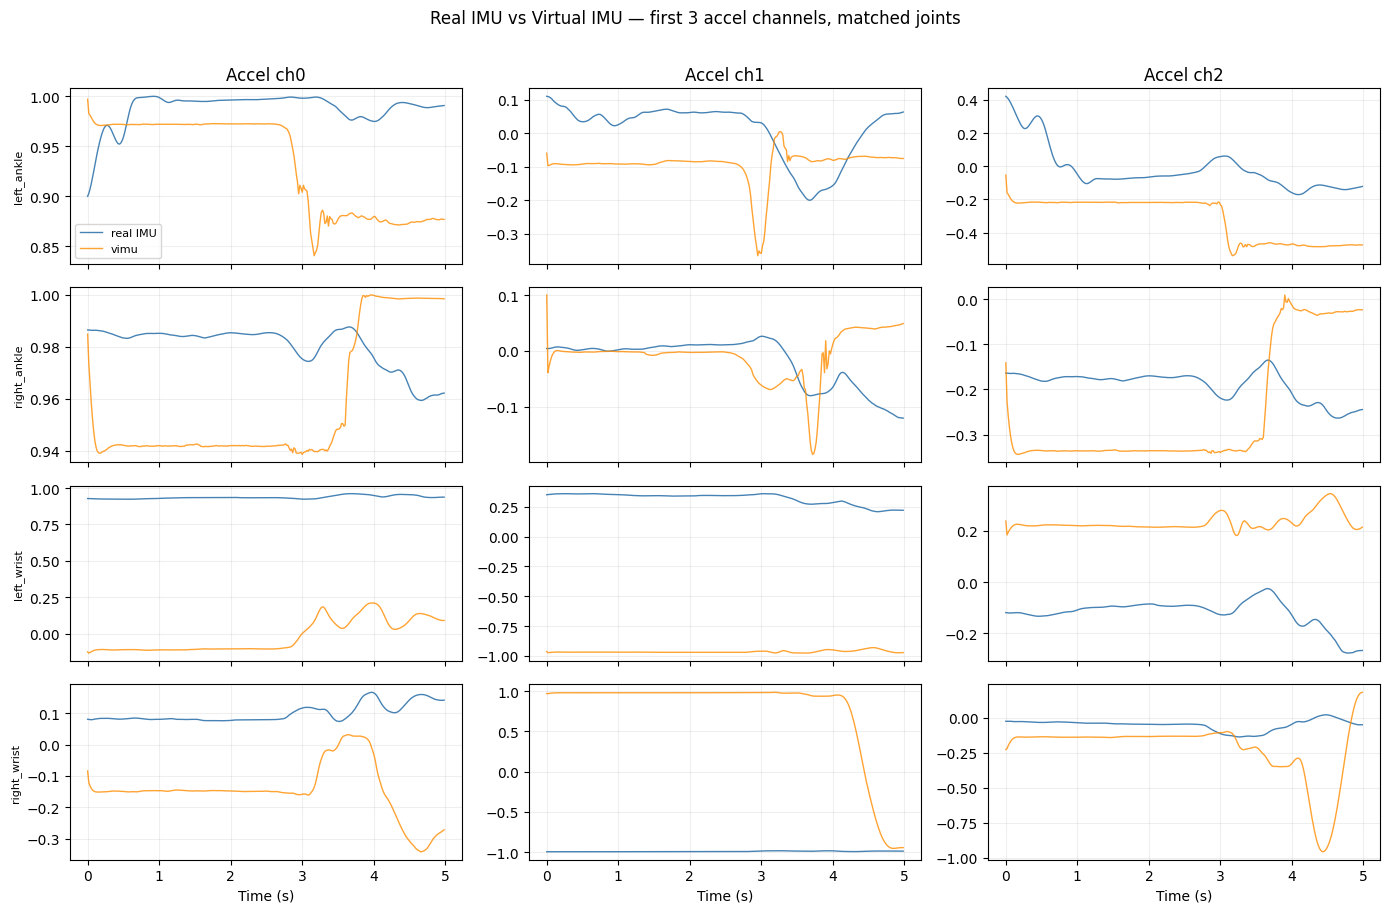

Pearson correlation (real vs vimu, channel 0):
  left_ankle     : r = -0.0510
  right_ankle    : r = -0.7628
  left_wrist     : r = 0.6443
  right_wrist    : r = -0.2413


In [8]:
vimu = d['vimu']['vimu_joints'].numpy()   # [300, 24, 9]

# Compare vimu at IMU_JOINTS positions against real IMU for matched sensors
# Sensor 0 → joint 7 (left_ankle), Sensor 1 → joint 8 (right_ankle)
compare_pairs = [
    (0, 7,  'left_ankle'),
    (1, 8,  'right_ankle'),
    (4, 20, 'left_wrist'),
    (5, 21, 'right_wrist'),
]

fig, axes = plt.subplots(len(compare_pairs), 3, figsize=(14, 9), sharex=True)
ch_labels = ['Accel ch0', 'Accel ch1', 'Accel ch2']

for row, (sensor_i, joint_i, name) in enumerate(compare_pairs):
    for col in range(3):
        ax = axes[row, col]
        ax.plot(t_ax, imu[:, sensor_i, col],  lw=1.0, label='real IMU', color='steelblue')
        ax.plot(t_ax, vimu[:, joint_i, col],  lw=1.0, label='vimu',     color='darkorange', alpha=0.8)
        if row == 0:
            ax.set_title(ch_labels[col])
        if col == 0:
            ax.set_ylabel(name, fontsize=8)
        ax.grid(alpha=0.2)

axes[0, 0].legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel('Time (s)')
fig.suptitle('Real IMU vs Virtual IMU — first 3 accel channels, matched joints', y=1.01)
plt.tight_layout()
plt.show()

# Correlation between real and virtual IMU
print('Pearson correlation (real vs vimu, channel 0):')
for sensor_i, joint_i, name in compare_pairs:
    r = np.corrcoef(imu[:, sensor_i, 0], vimu[:, joint_i, 0])[0, 1]
    print(f'  {name:<15}: r = {r:.4f}')

---
## 8 — Value Range Statistics Across the Full Train Set

Samples 50 random train files to estimate global min/max and std for normalisation.

In [9]:
random.seed(0)
sample_files = random.sample(train_files, 50)

vimu_all, imu_all, pos_all, vel_all = [], [], [], []

for f in tqdm(sample_files, desc='Loading sample'):
    data = torch.load(f, map_location='cpu', weights_only=False)
    vimu_all.append(data['vimu']['vimu_joints'].numpy())
    imu_all.append(data['imu']['imu'].numpy())
    pos_all.append(data['joint']['position'].numpy())
    vel_all.append(data['joint']['velocity'].numpy())

vimu_cat = np.concatenate(vimu_all, axis=0)   # [N*300, 24, 9]
imu_cat  = np.concatenate(imu_all,  axis=0)   # [N*300, 17, 9]
pos_cat  = np.concatenate(pos_all,  axis=0)   # [N*300, 24, 3]
vel_cat  = np.concatenate(vel_all,  axis=0)   # [N*300, 24, 3]

def print_stats(name, arr):
    flat = arr.reshape(-1)
    print(f'{name:<20}  mean={flat.mean():>8.4f}  std={flat.std():>7.4f}  '
          f'min={flat.min():>8.4f}  max={flat.max():>8.4f}')

print(f'Statistics from {len(sample_files)} random train files:')
print_stats('vimu_joints', vimu_cat)
print_stats('real IMU',    imu_cat)
print_stats('joint pos',   pos_cat)
print_stats('joint vel',   vel_cat)

# Per-channel stats for vimu
print()
print('vimu_joints per-channel (mean across joints):')
for ch in range(9):
    v = vimu_cat[:, :, ch].reshape(-1)
    print(f'  ch{ch}: mean={v.mean():7.3f}  std={v.std():7.3f}  min={v.min():8.3f}  max={v.max():8.3f}')

Loading sample: 100%|██████████| 50/50 [00:00<00:00, 514.82it/s]

Statistics from 50 random train files:
vimu_joints           mean=  0.1338  std= 1.8511  min=-63.9054  max=192.0978
real IMU              mean=  0.1262  std= 1.8358  min=-89.8465  max= 88.1938
joint pos             mean=  0.0273  std= 0.3054  min= -1.0167  max=  1.1244
joint vel             mean=  0.0003  std= 0.3021  min= -6.1727  max=  5.2451

vimu_joints per-channel (mean across joints):
  ch0: mean=  0.507  std=  0.578  min=  -1.000  max=   1.000
  ch1: mean= -0.002  std=  0.470  min=  -1.000  max=   1.000
  ch2: mean= -0.021  std=  0.433  min=  -1.000  max=   1.000
  ch3: mean= -0.008  std=  0.428  min=  -1.000  max=   1.000
  ch4: mean=  0.709  std=  0.407  min=  -0.996  max=   1.000
  ch5: mean=  0.030  std=  0.385  min=  -1.000  max=   1.000
  ch6: mean= -0.006  std=  3.420  min= -57.562  max=  81.096
  ch7: mean= -0.007  std=  3.148  min= -63.905  max=  53.695
  ch8: mean=  0.002  std=  2.719  min= -51.250  max= 192.098


---
## 9 — Per-Joint Motion Statistics

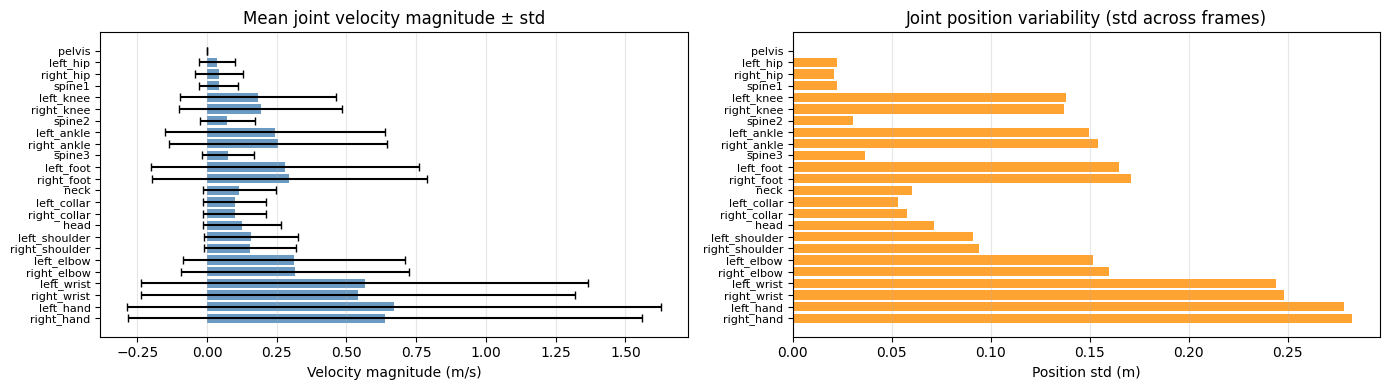

In [10]:
# Mean velocity magnitude per joint across sampled files
vel_mag = np.linalg.norm(vel_cat, axis=-1)   # [N*300, 24]
mean_vel_per_joint = vel_mag.mean(axis=0)    # [24]
std_vel_per_joint  = vel_mag.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Mean velocity bar chart
y_pos = np.arange(N_JOINTS)
axes[0].barh(y_pos, mean_vel_per_joint, xerr=std_vel_per_joint,
             color='steelblue', alpha=0.8, capsize=3)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(JOINT_NAMES, fontsize=8)
axes[0].set_xlabel('Velocity magnitude (m/s)')
axes[0].set_title('Mean joint velocity magnitude ± std')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Position std across time (how much each joint moves)
pos_std_per_joint = pos_cat.std(axis=0).mean(axis=-1)   # [24]
axes[1].barh(y_pos, pos_std_per_joint, color='darkorange', alpha=0.8)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(JOINT_NAMES, fontsize=8)
axes[1].set_xlabel('Position std (m)')
axes[1].set_title('Joint position variability (std across frames)')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 10 — Cross-Joint Correlation Heatmap

How correlated are the velocity magnitudes of different joints? High correlation → kinematically coupled.

/Users/aliasgar/Desktop/Ali Asgar/Projects/IMUCOCO/IMUCoCo/venv/lib/python3.10/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/aliasgar/Desktop/Ali Asgar/Projects/IMUCOCO/IMUCoCo/venv/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


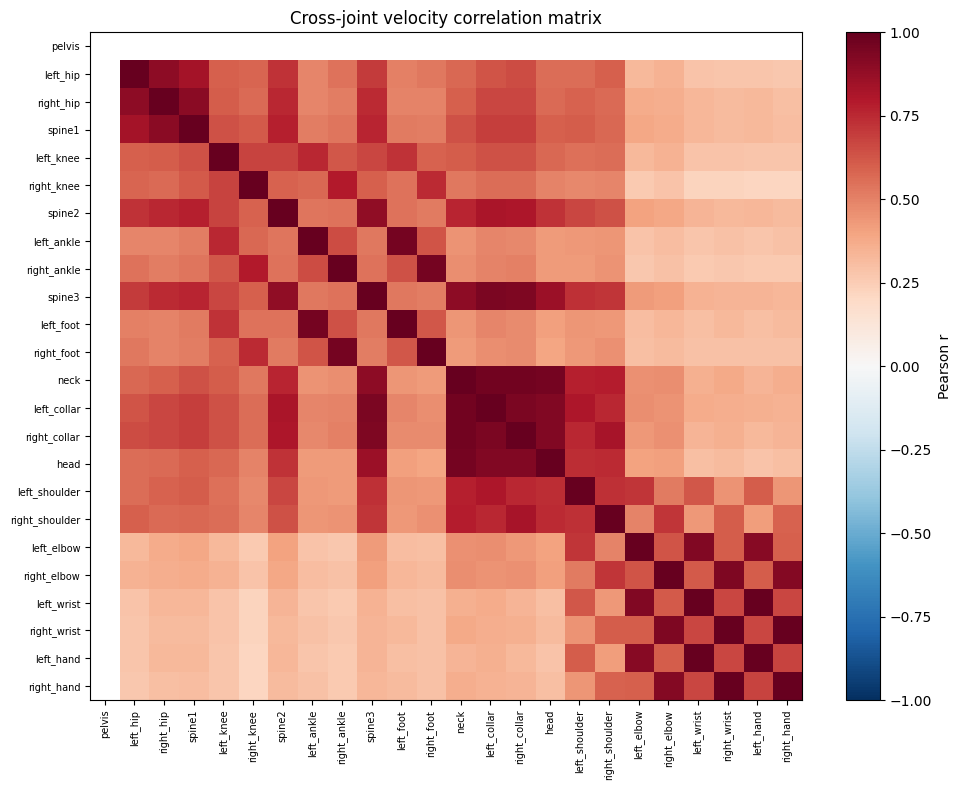

Top 10 most correlated pairs:
  pelvis               ↔ left_hip              r=nan
  pelvis               ↔ right_hip             r=nan
  pelvis               ↔ spine1                r=nan
  pelvis               ↔ left_knee             r=nan
  pelvis               ↔ right_knee            r=nan
  pelvis               ↔ spine2                r=nan
  pelvis               ↔ left_ankle            r=nan
  pelvis               ↔ right_ankle           r=nan
  pelvis               ↔ spine3                r=nan
  pelvis               ↔ left_foot             r=nan

Top 10 least correlated pairs:
  pelvis               ↔ left_hip              r=nan
  pelvis               ↔ right_hip             r=nan
  pelvis               ↔ spine1                r=nan
  pelvis               ↔ left_knee             r=nan
  pelvis               ↔ right_knee            r=nan
  pelvis               ↔ spine2                r=nan
  pelvis               ↔ left_ankle            r=nan
  pelvis               ↔ right_ankle 

In [11]:
# Correlation matrix of per-joint velocity magnitudes [N*300, 24]
corr_matrix = np.corrcoef(vel_mag.T)   # [24, 24]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_xticks(range(N_JOINTS))
ax.set_yticks(range(N_JOINTS))
ax.set_xticklabels(JOINT_NAMES, rotation=90, fontsize=7)
ax.set_yticklabels(JOINT_NAMES, fontsize=7)
ax.set_title('Cross-joint velocity correlation matrix')
plt.tight_layout()
plt.show()

# Most and least correlated pairs (excluding diagonal)
pairs = [(corr_matrix[i, j], JOINT_NAMES[i], JOINT_NAMES[j])
         for i in range(N_JOINTS) for j in range(i+1, N_JOINTS)]
pairs.sort(reverse=True)
print('Top 10 most correlated pairs:')
for r, a, b in pairs[:10]:
    print(f'  {a:<20} ↔ {b:<20}  r={r:.4f}')
print()
print('Top 10 least correlated pairs:')
for r, a, b in sorted(pairs)[:10]:
    print(f'  {a:<20} ↔ {b:<20}  r={r:.4f}')

---
## 11 — Foot Contact Label Analysis

Left  foot contact  — proportion in contact: 0.801
Right foot contact  — proportion in contact: 0.783
Both in contact     : 0.734
Only left           : 0.067
Only right          : 0.049
Neither             : 0.150


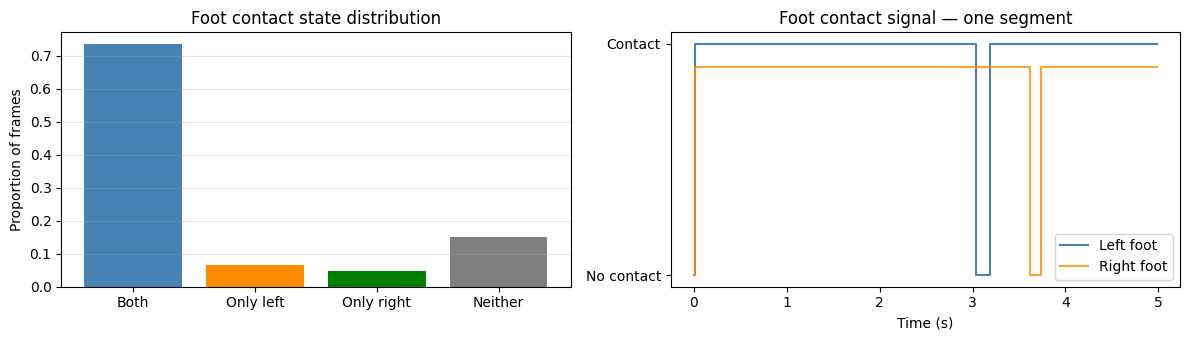

In [12]:
# Aggregate foot contact stats across sampled files
left_contact, right_contact = [], []
for f in sample_files:
    data = torch.load(f, map_location='cpu', weights_only=False)
    ft = data['gt']['ft_contact'].numpy()   # [300, 2]
    left_contact.append(ft[:, 0])
    right_contact.append(ft[:, 1])

left_all  = np.concatenate(left_contact)
right_all = np.concatenate(right_contact)

print(f'Left  foot contact  — proportion in contact: {left_all.mean():.3f}')
print(f'Right foot contact  — proportion in contact: {right_all.mean():.3f}')

both   = ((left_all == 1) & (right_all == 1)).mean()
neither = ((left_all == 0) & (right_all == 0)).mean()
only_l = ((left_all == 1) & (right_all == 0)).mean()
only_r = ((left_all == 0) & (right_all == 1)).mean()

print(f'Both in contact     : {both:.3f}')
print(f'Only left           : {only_l:.3f}')
print(f'Only right          : {only_r:.3f}')
print(f'Neither             : {neither:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

# Bar chart of contact states
states = ['Both', 'Only left', 'Only right', 'Neither']
vals   = [both, only_l, only_r, neither]
axes[0].bar(states, vals, color=['steelblue','darkorange','green','gray'])
axes[0].set_ylabel('Proportion of frames')
axes[0].set_title('Foot contact state distribution')
axes[0].grid(axis='y', alpha=0.3)

# Time series of one segment
d_ft = torch.load(train_files[0], map_location='cpu', weights_only=False)
ft0  = d_ft['gt']['ft_contact'].numpy()
t_ax = np.arange(300) / 60.0
axes[1].step(t_ax, ft0[:, 0], where='post', label='Left foot',  color='steelblue')
axes[1].step(t_ax, ft0[:, 1] * 0.9, where='post', label='Right foot', color='darkorange', alpha=0.8)
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Foot contact signal — one segment')
axes[1].legend()
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['No contact', 'Contact'])

plt.tight_layout()
plt.show()

---
## 12 — Train vs Test Distribution Shift

Compares velocity magnitude distributions between train subjects and test subjects to check for domain shift.

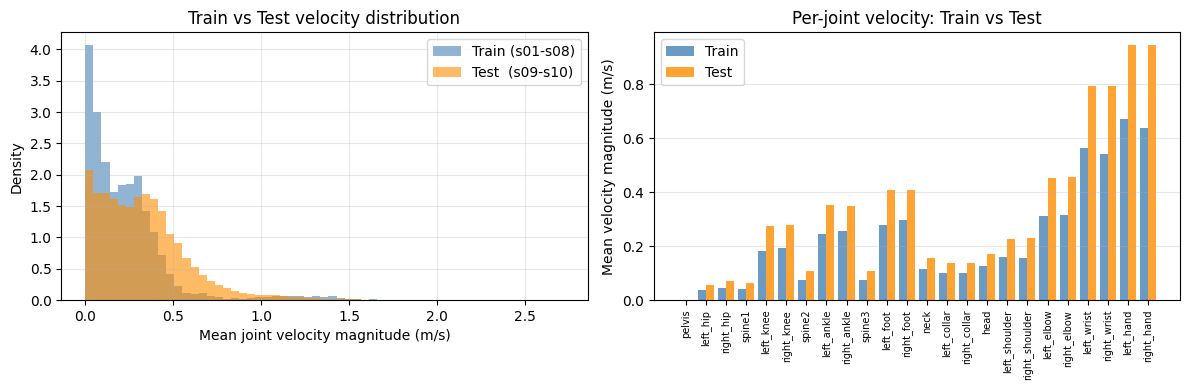

In [13]:
# Load test velocity data
test_vel_mags = []
for f in test_files:
    data = torch.load(f, map_location='cpu', weights_only=False)
    vel  = data['joint']['velocity'].numpy()
    test_vel_mags.append(np.linalg.norm(vel, axis=-1).mean(axis=-1))  # [T]

test_vel_all = np.concatenate(test_vel_mags)   # all test frames
train_vel_all = vel_mag.mean(axis=-1)           # sampled train frames

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overlapping histograms
bins = np.linspace(0, max(train_vel_all.max(), test_vel_all.max()), 60)
axes[0].hist(train_vel_all, bins=bins, density=True, alpha=0.6,
             label=f'Train (s01-s08)', color='steelblue')
axes[0].hist(test_vel_all,  bins=bins, density=True, alpha=0.6,
             label=f'Test  (s09-s10)', color='darkorange')
axes[0].set_xlabel('Mean joint velocity magnitude (m/s)')
axes[0].set_ylabel('Density')
axes[0].set_title('Train vs Test velocity distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Per-joint velocity magnitude: train vs test
test_vel_cat = np.concatenate(
    [torch.load(f, map_location='cpu', weights_only=False)['joint']['velocity'].numpy()
     for f in test_files], axis=0
)   # [total_T, 24, 3]
test_vel_mag_per_joint = np.linalg.norm(test_vel_cat, axis=-1).mean(axis=0)  # [24]

x = np.arange(N_JOINTS)
w = 0.4
axes[1].bar(x - w/2, mean_vel_per_joint,      width=w, label='Train', color='steelblue', alpha=0.8)
axes[1].bar(x + w/2, test_vel_mag_per_joint,  width=w, label='Test',  color='darkorange', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(JOINT_NAMES, rotation=90, fontsize=7)
axes[1].set_ylabel('Mean velocity magnitude (m/s)')
axes[1].set_title('Per-joint velocity: Train vs Test')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 13 — vimu_joints Channel Distributions

Histograms for all 9 channels of `vimu_joints` — useful for deciding normalisation strategy.

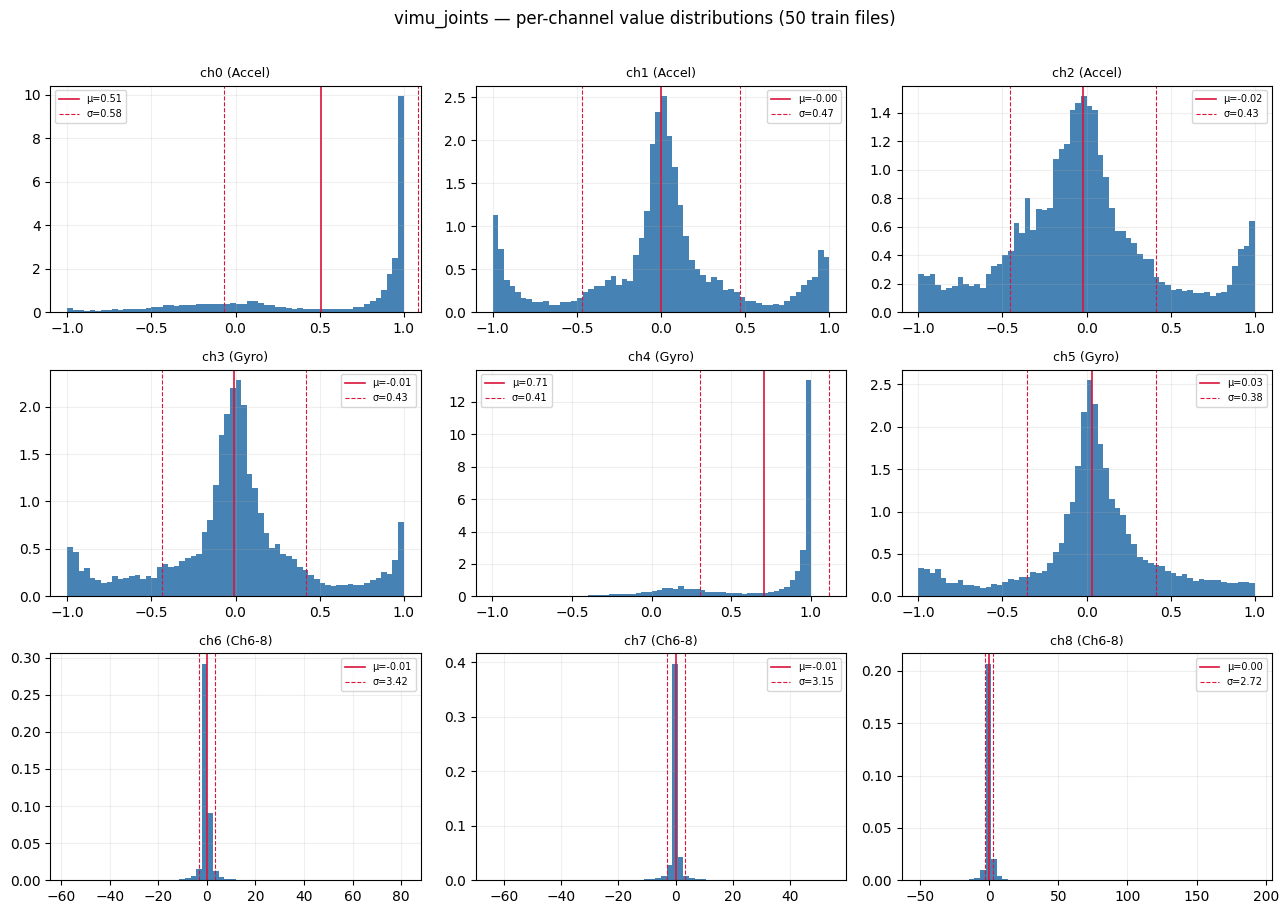

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
ch_group = ['Accel'] * 3 + ['Gyro'] * 3 + ['Ch6-8'] * 3

for ch, ax in enumerate(axes.flat):
    vals = vimu_cat[:, :, ch].reshape(-1)
    ax.hist(vals, bins=60, color='steelblue', edgecolor='none', density=True)
    ax.axvline(vals.mean(), color='crimson', lw=1.2, label=f'μ={vals.mean():.2f}')
    ax.axvline(vals.mean() + vals.std(), color='crimson', lw=0.8, linestyle='--',
               label=f'σ={vals.std():.2f}')
    ax.axvline(vals.mean() - vals.std(), color='crimson', lw=0.8, linestyle='--')
    ax.set_title(f'ch{ch} ({ch_group[ch]})', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)

fig.suptitle('vimu_joints — per-channel value distributions (50 train files)', y=1.01)
plt.tight_layout()
plt.show()

---
## 14 — Summary Statistics

In [15]:
total_train_frames = len(train_files) * 300
total_test_frames  = sum(test_lens.values())

print('=' * 55)
print('DATASET SUMMARY')
print('=' * 55)
print(f'Train files        : {len(train_files):>6}  (all T=300)')
print(f'Train subjects     : {len(train_subjects):>6}  ({train_subjects})')
print(f'Train total frames : {total_train_frames:>6,}  ({total_train_frames/60/60:.2f} hrs @ 60fps)')
print()
print(f'Test  files        : {len(test_files):>6}  (variable T)')
print(f'Test  subjects     : {len(test_subjects):>6}  ({test_subjects})')
print(f'Test  total frames : {total_test_frames:>6,}  ({total_test_frames/60/60:.2f} hrs @ 60fps)')
print()
print('Modalities in each .pt file:')
print('  vimu_joints   [T, 24,  9]  virtual IMU at each SMPL joint')
print('  imu           [T, 17,  9]  real IMU (17 physical sensors)')
print('  joint/pos     [T, 24,  3]  3D positions   (metres)')
print('  joint/vel     [T, 24,  3]  velocities')
print('  joint/ori     [T, 24,3,3]  rotation matrices')
print('  gt/pose_local [T, 24,3,3]  local joint rotations (GT)')
print('  gt/ft_contact [T,  2]      binary foot contact labels')
print()
print('vimu_joints global stats (from 50-file sample):')
flat = vimu_cat.reshape(-1)
print(f'  mean={flat.mean():.4f}  std={flat.std():.4f}  min={flat.min():.4f}  max={flat.max():.4f}')

DATASET SUMMARY
Train files        :    885  (all T=300)
Train subjects     :      8  (['s_01', 's_02', 's_03', 's_04', 's_05', 's_06', 's_07', 's_08'])
Train total frames : 265,500  (73.75 hrs @ 60fps)

Test  files        :     19  (variable T)
Test  subjects     :      2  (['s_09', 's_10'])
Test  total frames : 57,994  (16.11 hrs @ 60fps)

Modalities in each .pt file:
  vimu_joints   [T, 24,  9]  virtual IMU at each SMPL joint
  imu           [T, 17,  9]  real IMU (17 physical sensors)
  joint/pos     [T, 24,  3]  3D positions   (metres)
  joint/vel     [T, 24,  3]  velocities
  joint/ori     [T, 24,3,3]  rotation matrices
  gt/pose_local [T, 24,3,3]  local joint rotations (GT)
  gt/ft_contact [T,  2]      binary foot contact labels

vimu_joints global stats (from 50-file sample):
  mean=0.1338  std=1.8511  min=-63.9054  max=192.0978
